In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)

In [3]:

tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_set = datasets.FashionMNIST(root="./data", train=True,  download=True, transform=tf)
val_set   = datasets.FashionMNIST(root="./data", train=False, download=True, transform=tf)
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=256, shuffle=False)

100%|██████████| 26.4M/26.4M [00:08<00:00, 3.10MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 391kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.36MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 6.22MB/s]


In [4]:
class FashionClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),

            nn.Linear(784,256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            nn.Linear(256,128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            nn.Linear(128,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64,10)
        )
    def forward(self, x):
        return self.network(x)
    
model = FashionClassifier().to(device)

print(model)

FashionClassifier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=128, out_features=64, bias=True)
    (10): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): ReLU()
    (12): Linear(in_features=64, out_features=10, bias=True)
  )
)


Epoch  1/15 | Train Loss: 0.3696, Acc: 0.8651 | Val Loss: 0.4139, Acc: 0.8510
Epoch  2/15 | Train Loss: 0.3169, Acc: 0.8857 | Val Loss: 0.3677, Acc: 0.8682
Epoch  4/15 | Train Loss: 0.2809, Acc: 0.8974 | Val Loss: 0.3426, Acc: 0.8753
Epoch  5/15 | Train Loss: 0.2611, Acc: 0.9035 | Val Loss: 0.3331, Acc: 0.8779
Epoch  6/15 | Train Loss: 0.2437, Acc: 0.9096 | Val Loss: 0.3232, Acc: 0.8835
Epoch  7/15 | Train Loss: 0.2402, Acc: 0.9116 | Val Loss: 0.3237, Acc: 0.8836
Epoch  8/15 | Train Loss: 0.2287, Acc: 0.9160 | Val Loss: 0.3225, Acc: 0.8854
Epoch  9/15 | Train Loss: 0.2102, Acc: 0.9226 | Val Loss: 0.3087, Acc: 0.8873
Epoch 10/15 | Train Loss: 0.1991, Acc: 0.9271 | Val Loss: 0.3046, Acc: 0.8895
Epoch 11/15 | Train Loss: 0.1883, Acc: 0.9312 | Val Loss: 0.2910, Acc: 0.8951
Epoch 12/15 | Train Loss: 0.1826, Acc: 0.9335 | Val Loss: 0.2927, Acc: 0.8954
Epoch 13/15 | Train Loss: 0.1754, Acc: 0.9362 | Val Loss: 0.2902, Acc: 0.8966
Epoch 15/15 | Train Loss: 0.1704, Acc: 0.9390 | Val Loss: 0.2875

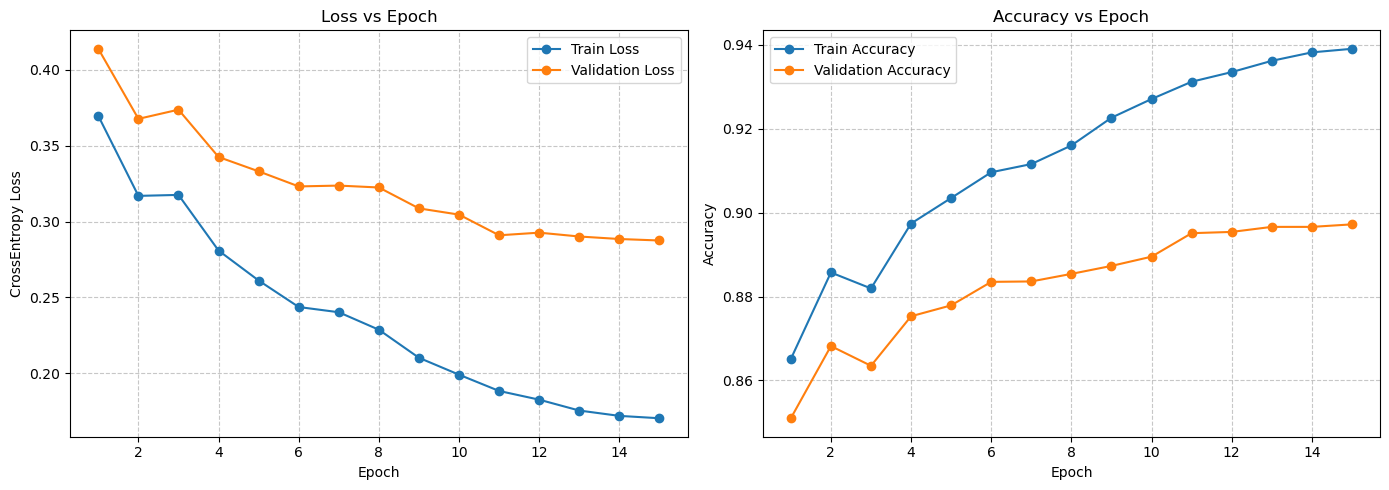

In [5]:
epochs = 15
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max = epochs)
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0.0
best_epoch = 0

def evaluate(loader):
    model.eval()
    running_loss = 0.0
    correct = 0 
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs,1)
            total+= labels.size(0)
            correct += (predicted == labels).sum().item()
        return running_loss/total, correct/total
for epoch in range(epochs):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    scheduler.step()
    train_loss,train_acc = evaluate(train_loader)
    val_loss, val_acc = evaluate(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_acc>best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1

        print(f"Epoch {epoch+1:2d}/{epochs} | "
        f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

print(f"\nBest Validation Accuracy: {best_val_acc:.4f} at Epoch {best_epoch}")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, epochs+1), val_losses, label='Validation Loss', marker='o')
plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('CrossEntropy Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), train_accs, label='Train Accuracy', marker='o')
plt.plot(range(1, epochs+1), val_accs, label='Validation Accuracy', marker='o')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()